In [1]:
import torch
from torch import nn
import torch.nn.functional as F 
from torch.utils.data import DataLoader
import torchvision.utils
from torchvision.models import resnet50, ResNet50_Weights

from torchvision.transforms import Compose, RandomHorizontalFlip, Normalize, Resize
from transform import show, Rotate
from dataset_build import mias, build_train_test_datasets

from torch.utils.tensorboard import SummaryWriter

import os
cwd = os.getcwd()
str = os.path.join('/', *cwd.split('/')[:cwd.split('/').index('all-mias')+1])
%cd $str

/Users/parsa/Desktop/AI/A-level/Code/all-mias


In [15]:
#writer = SummaryWriter('runs/first_linear')

In [2]:
tforms = Compose([
    RandomHorizontalFlip(),
    Rotate(-30, 30, 0.3),
    Normalize((54.35747528076172,), (71.1281967163086,)) #calculated in std_mean.py
])

tforms_2 = lambda x: x/255 

def custom_tform(labels):
    return labels[0].to(torch.int64)

In [3]:
train_df, test_df = build_train_test_datasets(
                'dataset_all_mias/labels/label_encoded_dataset.csv', 
               'dataset_all_mias/dataset_jpeg', 
               train_transform=tforms_2, 
               test_transform=tforms_2,
               train_target_transofrm=custom_tform,
               test_target_transform=custom_tform)

In [4]:
train_load, test_load = DataLoader(train_df, batch_size=10), DataLoader(test_df, batch_size=10)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

#classes = {'CIRC': 0, 'NORM': 1, 'MISC': 2, 'ASYM': 3, 'ARCH': 4, 'SPIC': 5, 'CALC': 6}
classes = {0: 'CIRC', 1: 'NORM', 2: 'MISC', 3: 'ASYM', 4: 'ARCH', 5: 'SPIC', 6: 'CALC'}


Using mps device


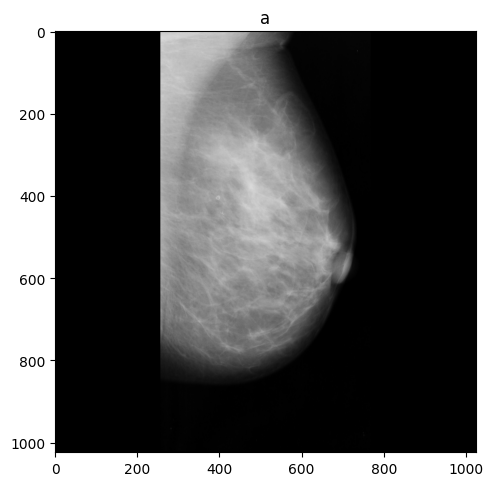

In [6]:
show(1,1, a=train_df[0][0] )

In [20]:
#writer.add_images('First batch images', next(iter(train_load))[0], 0, dataformats='NCHW')
#writer.flush()

In [21]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model_conv = resnet50(weights=weights)

for param in model_conv.parameters():
    param.requires_grad = False

In [22]:
import os
import torch

print(torch.hub.get_dir())

/Users/parsa/.cache/torch/hub


In [23]:
class GarmentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = model_conv
        self.fc1 = nn.Linear(1000,100)
        self.fc2 = nn.Linear(100, 7)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.resnet(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [24]:
model = GarmentClassifier().to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [13]:
model(next(iter(train_load))[0].to(device))

torch.Size([10, 1000])


tensor([[-1.5074e-02, -6.5162e-02, -8.5879e-03,  5.2230e-02, -3.7192e-02,
         -1.0580e-01, -1.1440e-01],
        [-6.0355e-02, -1.2817e-01,  2.7867e-02,  1.1097e-01, -1.2462e-01,
         -1.2112e-01, -8.3941e-02],
        [-7.4292e-03, -4.0121e-02, -2.0843e-02,  1.0010e-01, -4.2609e-02,
         -9.4844e-02, -6.6718e-02],
        [-3.3998e-03, -6.2943e-02,  1.1392e-04,  6.3605e-02, -2.0996e-02,
         -1.1162e-01, -1.1107e-01],
        [-3.3600e-02, -5.4559e-02, -2.7246e-02,  7.3839e-02, -2.6744e-02,
         -9.5321e-02, -1.2503e-01],
        [ 1.8678e-02, -1.1217e-01,  2.8293e-02,  1.6248e-02, -1.9234e-03,
         -7.3914e-02, -1.5627e-01],
        [-2.9352e-02, -9.5732e-02,  1.6438e-02,  4.3278e-02, -2.8802e-02,
         -1.1759e-01, -1.2345e-01],
        [-2.8313e-02, -6.8777e-02, -3.5971e-03,  5.6624e-02, -4.8152e-02,
         -6.4719e-02, -8.5950e-02],
        [-4.5510e-02, -2.6755e-02,  2.6801e-02,  8.2567e-02, -3.9596e-02,
         -1.2656e-01, -1.0538e-01],
        [-

In [25]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [26]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [27]:
epochs = 200
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_load, model, loss_fn, optimizer)
    test(test_load, model, loss_fn)
print("Done!")


Epoch 1
-------------------------------
loss: 1.857715  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.696583 

Epoch 2
-------------------------------
loss: 1.676697  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.567408 

Epoch 3
-------------------------------
loss: 1.467394  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.276978 

Epoch 4
-------------------------------
loss: 1.375753  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.208327 

Epoch 5
-------------------------------
loss: 1.340270  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.212267 

Epoch 6
-------------------------------
loss: 1.312736  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.206752 

Epoch 7
-------------------------------
loss: 1.292086  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.199807 

Epoch 8
-------------------------------
loss: 1.276892  [   10/  261]
Test Error: 
 Accuracy: 71.2%, Avg loss: 1.193633 

Epoch 9
----------------

KeyboardInterrupt: 

In [ ]:
import numpy as np
torch.set_printoptions(sci_mode=False)

In [ ]:
gpuified = [test_df[a][0][None, ...].to(device) for a in range(10)]

In [ ]:
a = 3
soft = nn.Softmax()

print(soft(model(gpuified[a]))*100)
print(test_df[a][1])

tensor([[13.3322, 60.8494,  0.0647,  1.6600,  0.0829,  0.6445, 23.3664]],
       device='mps:0', grad_fn=<MulBackward0>)
tensor(6)
